In [1]:
import numpy as np
import numba
import numba.cuda as cuda
import matplotlib.pyplot as plt

from gpu import CRUs, RyR_stationary, LCC_stationary, calculate_V_dep_LCC_params
from gpu.CRU3d import CRU3D
from params import RestrepoParams

In [2]:

def bubble_sort(ryr):
    srted = np.copy(ryr)

    swapped = False
    tmp = 0.0
    for i in range(3):
        swapped = False
        for j in range(3 - i):
            if srted[j] > srted[j + 1]:
                tmp = srted[j]
                srted[j] = srted[j + 1]
                srted[j + 1] = tmp
                swapped = True
        if not swapped:
            break
    return srted

def orth_proj(ryr):
    #srted = bubble_sort(ryr)
    srted = np.sort(ryr)
    t = 0.0
    sum_ = 0.0
    for i in range(len(ryr)):
        if i == len(ryr)-1:
            t = (ryr.sum() - 1) / len(ryr)
            break
        sum_ += srted[len(ryr)-1-i]
        t = (sum_ - 1) / (i+1)
        if t >= srted[len(ryr)-2-i]:
            break
    out = np.copy(ryr)
    out[:] = np.where(ryr - t > 0, ryr - t, 0)
    return out

In [3]:
orth_proj(np.array([0.99, -0.01, -0.02]))

array([1.00000000e+00, 8.67361738e-18, 0.00000000e+00])

In [4]:
orth_proj(np.array([0.99, 0.01, -0.01, -0.02]))

array([0.99, 0.01, 0.  , 0.  ])

In [5]:
t = np.linspace(-0.5, 0.5, num=100)
arrys = [np.array([0.25 * t_, 0.25 * (1-t_), 0.25, 0.25]) for t_ in t]
projected = [orth_proj(arr) for arr in arrys]

In [6]:
print(arrys[2])
print(projected[2])

[-0.11994949  0.36994949  0.25        0.25      ]
[0.         0.41329966 0.29335017 0.29335017]


In [7]:
N = 20 * 20 * 60
vi = 0.5 * 19305 / N#10_000 / N
vs = vnsr = 0.025 * 19305 / N
vjsr = 0.02 * 19305 / N
vp = 0.00126 * 19305 / N
params = RestrepoParams(Ku=1.4e-4, h=2.5, tau_tr=6.60, BCSQN=460.0, tau_u=145.0, vup=0.36)#, vi=vi, vs=vs, vnsr=vnsr, vjsr=vjsr, vp=vp)

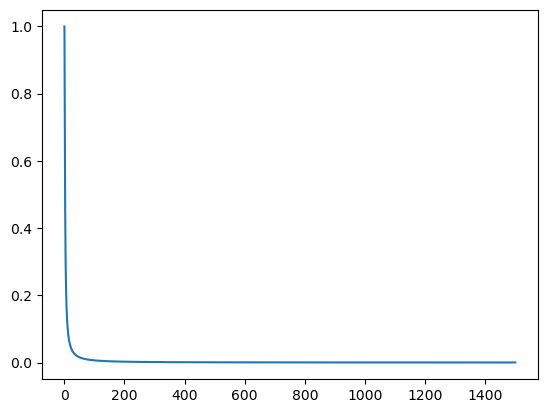

In [8]:
cjsr = np.linspace(0.1, 1500, num=10000)
rho = params.rho_inf / (1 + (params.K / cjsr) ** 2.5)
def Mhat_(rho, params):
    rhoBCSQN = rho * params.BCSQN
    return np.where(rhoBCSQN < 1e-10, 1.0 - 2.0 * rhoBCSQN, (np.sqrt(1.0 + 8.0 * rhoBCSQN) - 1.0) / (4.0 * rhoBCSQN))
Mhat = Mhat_(rho, params)
plt.plot(cjsr, Mhat)
plt.show()

In [9]:
def beta_j(rho, params):
    Mhat = Mhat_(rho, params)

    ncjsr = Mhat * params.nM + (1.0 - Mhat) * params.nD

    drho = (params.h * rho / cjsr) * (1.0 - rho / params.rho_inf)
    dMhat = (
        (-2.0 * params.BCSQN * Mhat**2)
        / (1.0 + 4.0 * Mhat * rho * params.BCSQN)
    ) * drho
    dn = dMhat * (params.nM - params.nD)

    return 1.0 / (1.0
        + params.BCSQN * (params.KC * ncjsr + dn * (cjsr * params.KC + cjsr**2)) / (params.KC + cjsr)**2
    )

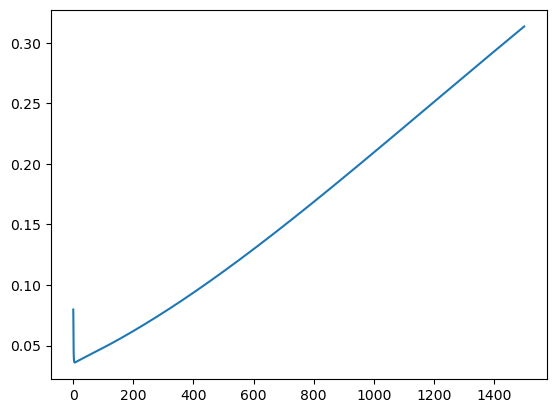

In [10]:
plt.plot(cjsr, beta_j(rho, params))
plt.show()

In [11]:
30 * beta_j(rho, params)[7000]

6.596370141123737

In [12]:
rho_ = params.rho_inf / (1 + (params.K / 1100) ** 2.5)
k14 = Mhat_(rho_, params) / params.tau_b
k41 = 1 / params.tau_u

In [13]:
ci = 0.2 * np.ones((60, 20, 20), dtype=np.float32)
cs = 0.2 * np.ones((60, 20, 20), dtype=np.float32)
cp = 0.2 * np.ones((60, 20, 20), dtype=np.float32)

cjsr = 1100.0 * np.ones((60, 20, 20), dtype=np.float32)
cnsr = 1100.0 * np.ones((60, 20, 20), dtype=np.float32)

CaTi = params.kon * params.BT * ci / (params.koff + params.kon * ci)
CaTs = params.kon * params.BT * cs / (params.koff + params.kon * cs)

RyR = np.zeros((60, 20, 20, 4), dtype=np.float32)
RyR[..., 0] = k41 / (k41 + k14)
RyR[..., 3] = 1 - RyR[..., 0]

LCC = np.ones((60, 20, 20, 4), dtype=np.int32)

vp = params.vp * np.ones_like(ci)

In [14]:
cru3d_diff = CRU3D(params, RyR, LCC, ci, cnsr, cjsr, cs, cp, CaTi, CaTs, vp=vp)
cru3d_tau = CRU3D(params, RyR, LCC, ci, cnsr, cjsr, cs, cp, CaTi, CaTs, vp=vp)

In [24]:
sol_diff = cru3d_diff.forward(1e-3, T=None, Nai=10.0, Vmax=0.0, Vmin=-85.0, nstep=50_000, collect_every=100, Po_shift=0.005, tpb=(16,4,4))

In [25]:
sol_tau = cru3d_tau.forward_tau_leap(1e-3, T=None, Nai=10.0, Vmax=0.0, Vmin=-85.0, nstep=50_000, collect_every=100, tpb=(16,4,4))

In [26]:
ICa_diff = sol_diff.ICa()
INCX_diff = sol_diff.INCX()

ICa_tau = sol_tau.ICa()
INCX_tau = sol_tau.INCX()

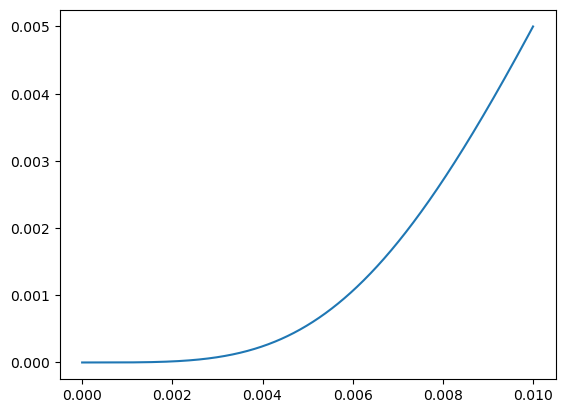

In [31]:
def Po_tempered(Po, thresh, exponent):
    return Po * Po**exponent / (Po**exponent + thresh**exponent)

Pos = np.linspace(0, 0.01, num=1000)
plt.plot(Pos, Po_tempered(Pos, 0.01, 3))
plt.show()

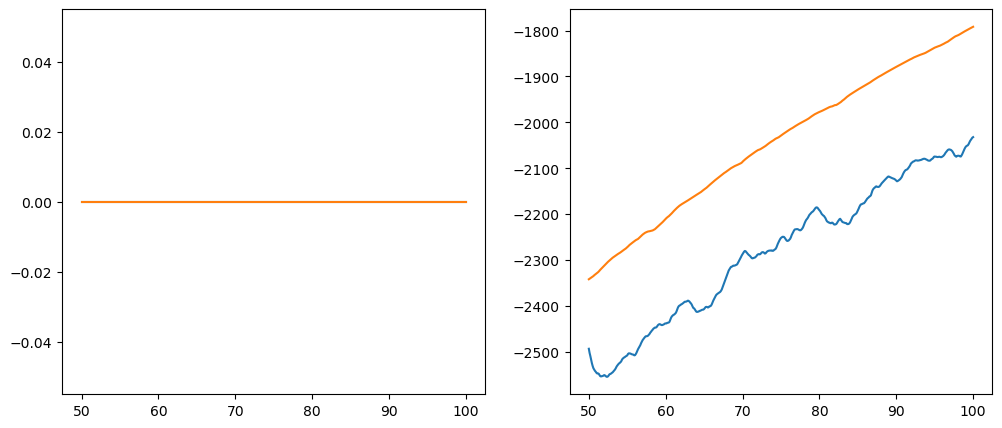

In [32]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(sol_diff.t, ICa_diff.sum(axis=(1,2,3)))
ax[0].plot(sol_diff.t, ICa_tau.sum(axis=(1,2,3)))
ax[1].plot(sol_diff.t, INCX_diff.sum(axis=(1,2,3)))
ax[1].plot(sol_diff.t, INCX_tau.sum(axis=(1,2,3)))
plt.show()

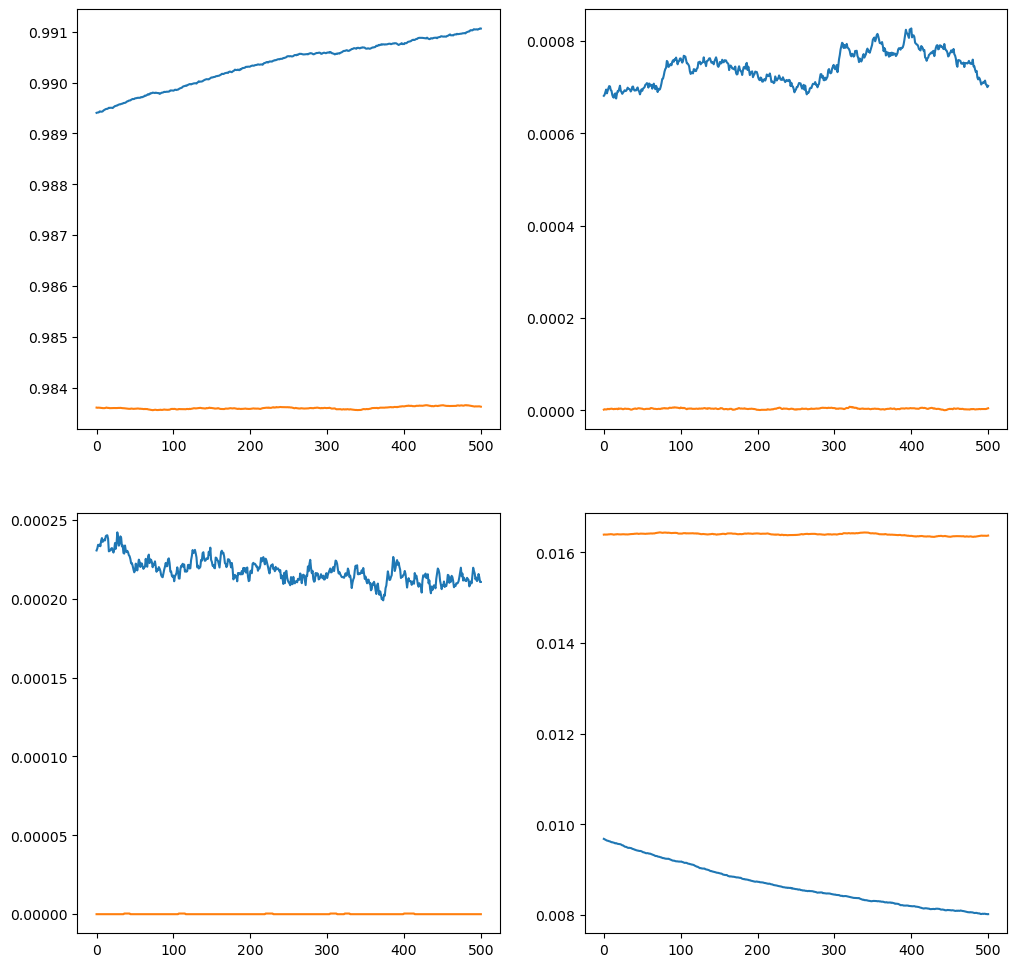

In [33]:
fig, ax = plt.subplots(2, 2, figsize=(12,12))
ax[0, 0].plot(sol_diff.RyR[..., 0].mean(axis=(1,2,3)))
ax[0, 0].plot(sol_tau.RyR[..., 0].mean(axis=(1,2,3)))

ax[0, 1].plot(sol_diff.RyR[..., 1].mean(axis=(1,2,3)))
ax[0, 1].plot(sol_tau.RyR[..., 1].mean(axis=(1,2,3)))

ax[1, 0].plot(sol_diff.RyR[..., 2].mean(axis=(1,2,3)))
ax[1, 0].plot(sol_tau.RyR[..., 2].mean(axis=(1,2,3)))

ax[1, 1].plot(sol_diff.RyR[..., 3].mean(axis=(1,2,3)))
ax[1, 1].plot(sol_tau.RyR[..., 3].mean(axis=(1,2,3)))
plt.show()

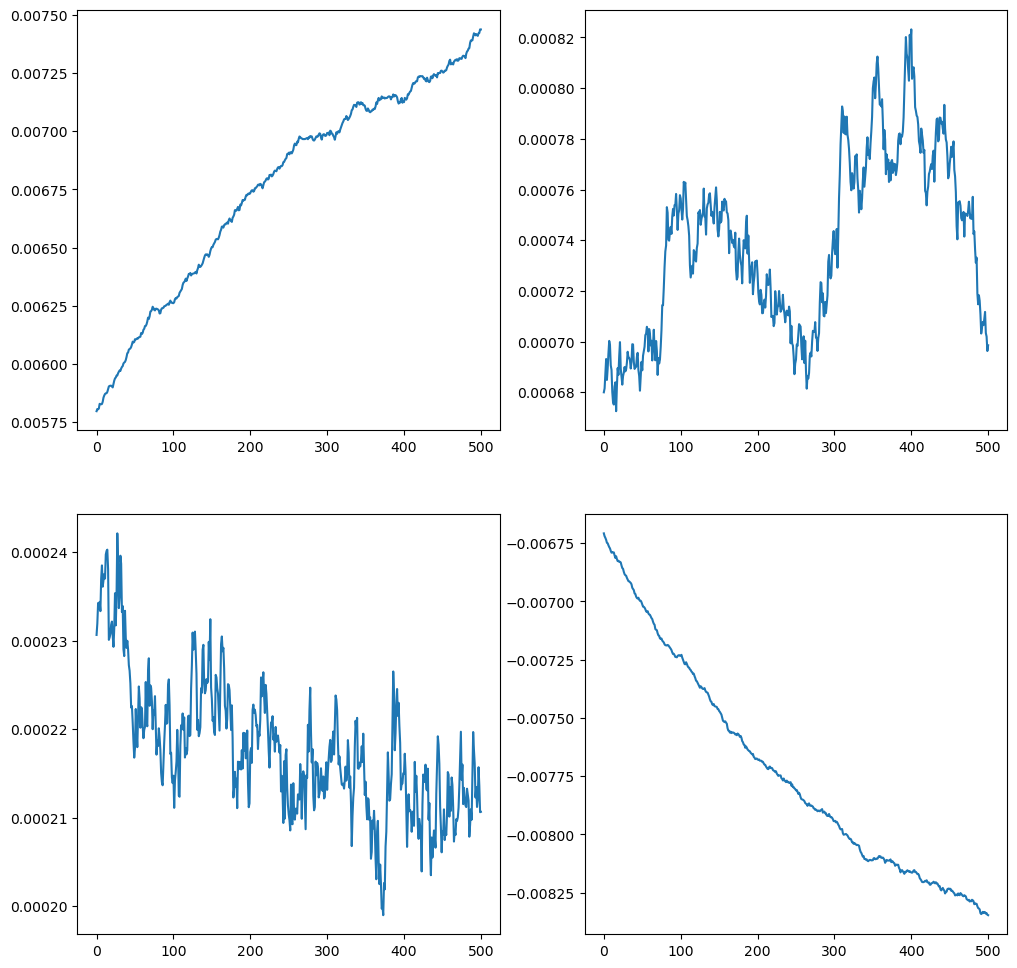

In [34]:
fig, ax = plt.subplots(2, 2, figsize=(12,12))
ax[0, 0].plot(sol_diff.RyR[..., 0].mean(axis=(1,2,3)) - sol_tau.RyR[..., 0].mean(axis=(1,2,3)))

ax[0, 1].plot(sol_diff.RyR[..., 1].mean(axis=(1,2,3)) - sol_tau.RyR[..., 1].mean(axis=(1,2,3)))

ax[1, 0].plot(sol_diff.RyR[..., 2].mean(axis=(1,2,3)) - sol_tau.RyR[..., 2].mean(axis=(1,2,3)))

ax[1, 1].plot(sol_diff.RyR[..., 3].mean(axis=(1,2,3)) - sol_tau.RyR[..., 3].mean(axis=(1,2,3)))
plt.show()

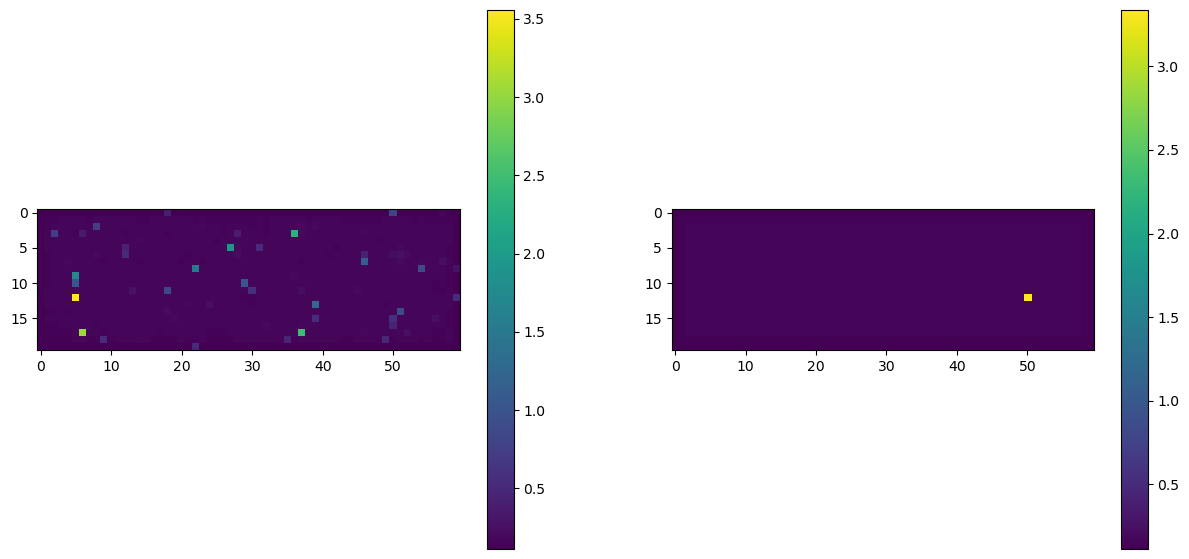

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(15,7))
p1 = ax[0].imshow(sol_diff.cp[-1, ..., 10].T)
p2 = ax[1].imshow(sol_tau.cp[-1, ..., 10].T)
fig.colorbar(p1)
fig.colorbar(p2)
plt.show()

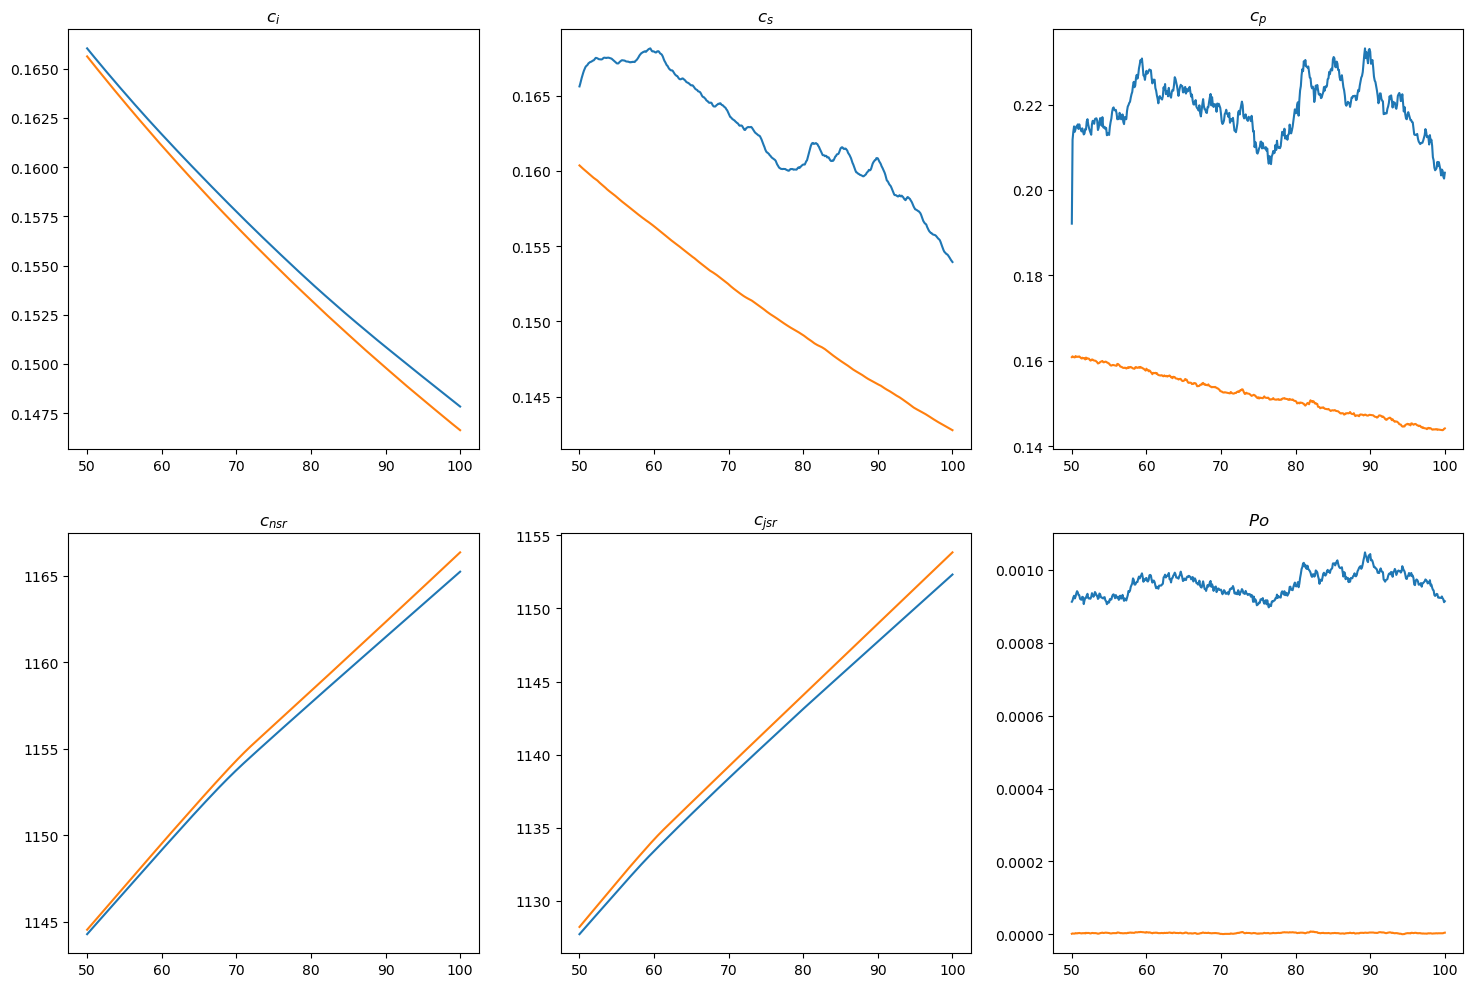

In [36]:
fig, ax = plt.subplots(2, 3, figsize=(18,12))
ax[0, 0].plot(sol_diff.t, sol_diff.ci.mean(axis=(1,2,3)))
ax[0, 0].plot(sol_tau.t, sol_tau.ci.mean(axis=(1,2,3)))
ax[0, 0].set_title(r"$c_i$")

ax[0, 1].plot(sol_diff.t, sol_diff.cs.mean(axis=(1,2,3)))
ax[0, 1].plot(sol_tau.t, sol_tau.cs.mean(axis=(1,2,3)))
ax[0, 1].set_title(r"$c_s$")

ax[0, 2].plot(sol_diff.t, sol_diff.cp.mean(axis=(1,2,3)))
ax[0, 2].plot(sol_tau.t, sol_tau.cp.mean(axis=(1,2,3)))
ax[0, 2].set_title(r"$c_p$")

ax[1, 0].plot(sol_diff.t, sol_diff.cnsr.mean(axis=(1,2,3)))
ax[1, 0].plot(sol_tau.t, sol_tau.cnsr.mean(axis=(1,2,3)))
ax[1, 0].set_title(r"$c_{nsr}$")

ax[1, 1].plot(sol_diff.t, sol_diff.cjsr.mean(axis=(1,2,3)))
ax[1, 1].plot(sol_tau.t, sol_tau.cjsr.mean(axis=(1,2,3)))
ax[1, 1].set_title(r"$c_{jsr}$")

ax[1, 2].plot(sol_diff.t, sol_diff.RyR[..., 1:3].sum(axis=-1).mean(axis=(1,2,3)))
ax[1, 2].plot(sol_tau.t, sol_tau.RyR[..., 1:3].sum(axis=-1).mean(axis=(1,2,3)))
ax[1, 2].set_title(r"$Po$")


plt.show()

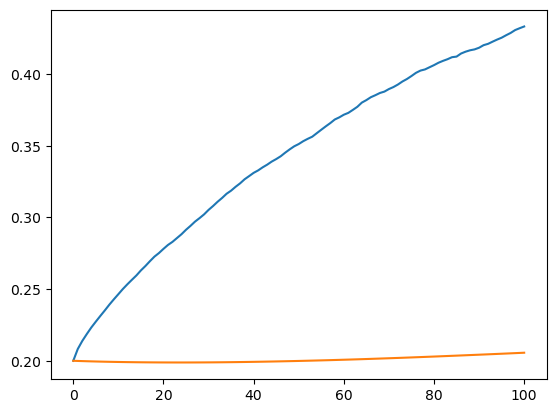

In [26]:
ryr_open = sol.RyR[..., 1] + sol.RyR[..., 2]
plt.plot(((sol.cs +  ryr_open * sol.cjsr * params.Jmax * params.tau_ps / params.vp) / (1 + params.Jmax * params.tau_ps * ryr_open / params.vp)).mean(axis=(1,2,3)))
plt.plot(sol.cs.mean(axis=(1,2,3)))
plt.show()

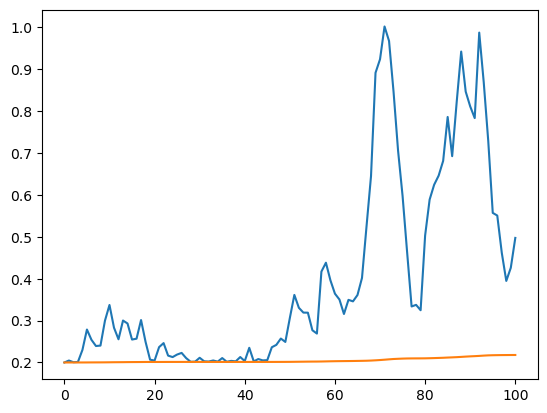

In [27]:
plt.plot((sol.cs[:, 2, 2, 2] + ryr_open[:, 2, 2, 2] * sol.cjsr[:, 2, 2, 2] * params.Jmax * params.tau_ps / params.vp) / (1 + params.Jmax * params.tau_ps * ryr_open[:, 2, 2, 2] / params.vp))
plt.plot(sol.cs[:, 2, 2, 2])
plt.show()

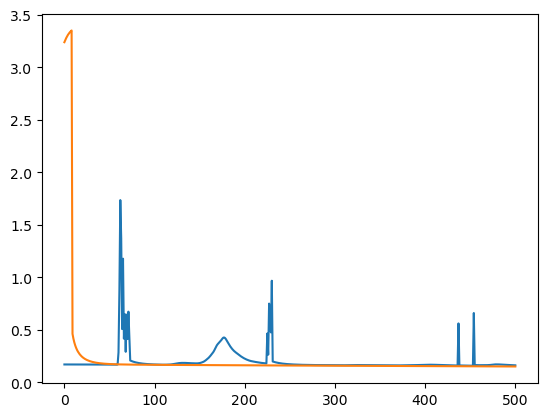

In [39]:
plt.plot(sol_diff.cp[:, 2, 2, 2])
plt.plot(sol_tau.cp[:, 57, 8, 4])
plt.show()

In [38]:
np.where(sol_tau.cp > 1.0)

(array([  0,   0,   0, ..., 500, 500, 500]),
 array([ 2, 27, 57, ..., 50, 54, 56]),
 array([ 0, 12,  8, ..., 12,  5,  2]),
 array([ 9,  0,  4, ..., 10,  1,  6]))

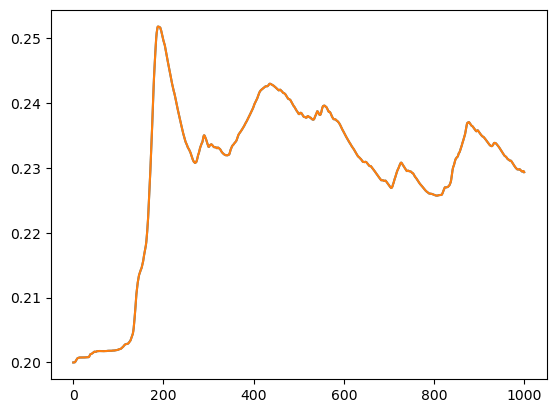

In [101]:
plt.plot((sol.cs[:, 2, 2, 2] + np.clip(ryr_open[:, 2, 2, 2]-0.01, a_min=0.0, a_max=1.0) * sol.cjsr[:, 2, 2, 2] * params.Jmax * params.tau_ps / params.vp) / (1 + params.Jmax * params.tau_ps * 0.1*ryr_open[:, 2, 2, 2] / params.vp))
plt.plot(sol.cs[:, 2, 2, 2])
plt.show()

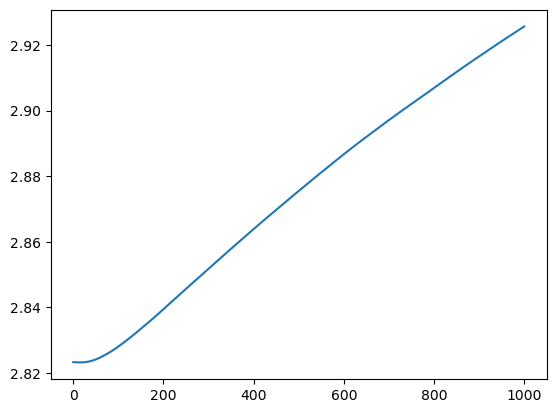

In [63]:
plt.plot((0.01 * sol.cjsr * params.Jmax * params.tau_ps / params.vp).mean(axis=(1,2,3)))
plt.show()

In [83]:
ci = 0.2 * np.ones((200, 200), dtype=np.float32)
cs = 0.2 * np.ones((200, 200), dtype=np.float32)
cp = 0.2 * np.ones((200, 200), dtype=np.float32)

cjsr = 1100.0 * np.ones((200,200), dtype=np.float32)
cnsr = 1100.0 * np.ones((200,200), dtype=np.float32)

CaTi = 17.5 * np.ones((200,200), dtype=np.float32)
CaTs = 17.5 * np.ones((200,200), dtype=np.float32)

vp = params.vp * np.ones_like(ci)

In [10]:
RyR = RyR_stationary(cp, params)

In [11]:
#LCC = LCC_stationary(cp, 0.1, params)
LCC = np.zeros((*cp.shape, 4), dtype=np.int32)
LCC[0, ...] = 1
LCC[-1, ...] = 1
LCC[:, 0, :] = 1
LCC[:, -1, :] = 1

In [12]:
cru_obj = CRUs(params, RyR, LCC, ci, cnsr, cjsr, cs, cp, CaTi, CaTs, vp=vp)

In [13]:
cru_obj.forward(dt=1e-2, nstep=100_000, collect_every=1000, tpb2d=(8,8), tpb1d=16)

/home/luke/anaconda3/lib/python3.11/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 50 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


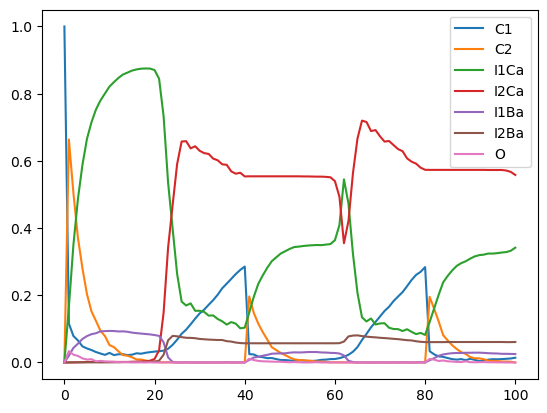

In [14]:
plt.plot((cru_obj.LCC_result == 1).sum(axis=(1,2,3)) / (796*4), label="C1")
plt.plot((cru_obj.LCC_result == 2).sum(axis=(1,2,3)) / (796*4), label="C2")
plt.plot((cru_obj.LCC_result == 3).sum(axis=(1,2,3)) / (796*4), label="I1Ca")
plt.plot((cru_obj.LCC_result == 4).sum(axis=(1,2,3)) / (796*4), label="I2Ca")
plt.plot((cru_obj.LCC_result == 5).sum(axis=(1,2,3)) / (796*4), label="I1Ba")
plt.plot((cru_obj.LCC_result == 6).sum(axis=(1,2,3)) / (796*4), label="I2Ba")
plt.plot((cru_obj.LCC_result == 7).sum(axis=(1,2,3)) / (796*4), label="O")
plt.legend()
plt.show()

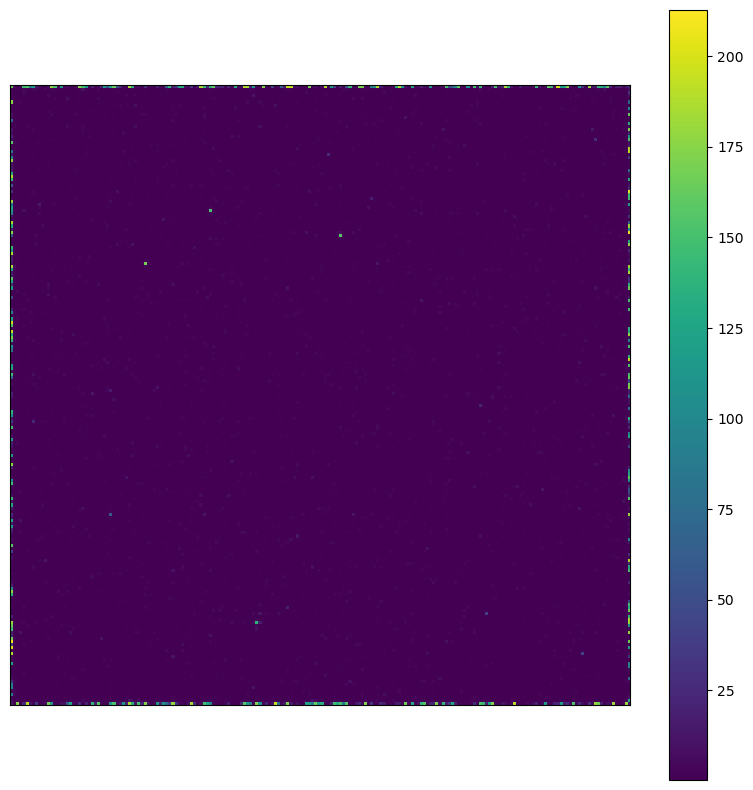

In [20]:
fig, ax = plt.subplots(1, figsize=(10,10))
im = ax.imshow(cru_obj.cp_result[1, ...], aspect='equal')
ax.set_yticks([])
ax.set_xticks([])
fig.colorbar(im)
plt.show()

In [17]:
ci_bdy = (cru_obj.ci_result[:, 0, :] + cru_obj.ci_result[:, -1, :] + cru_obj.ci_result[:, :, 0] + cru_obj.ci_result[:, :, -1]).sum(axis=1)

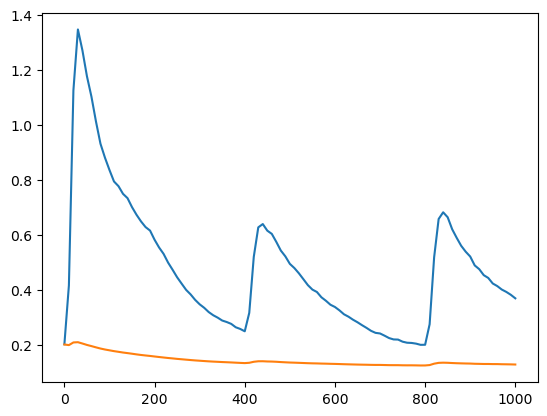

In [18]:
plt.plot(cru_obj.t, ci_bdy / (2*200 + 2*198))
plt.plot(cru_obj.t, cru_obj.ci_result.mean(axis=(1,2)))
plt.show()

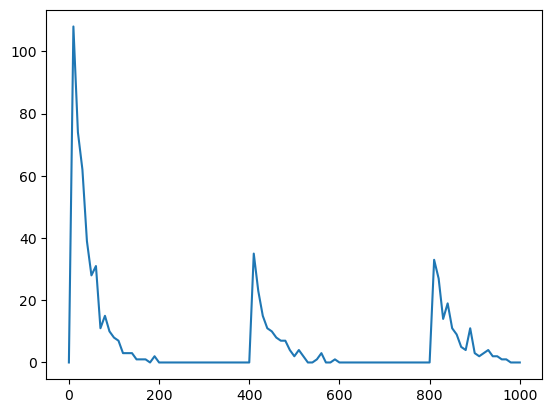

In [19]:
plt.plot(cru_obj.t, (cru_obj.LCC_result == 7).sum(axis=(1,2,3)))
plt.show()

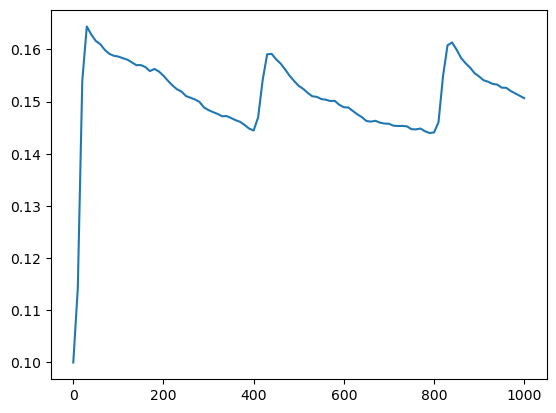

In [32]:
plt.plot(cru_obj.t, cru_obj.ci_result.mean(axis=(1,2)))
plt.show()

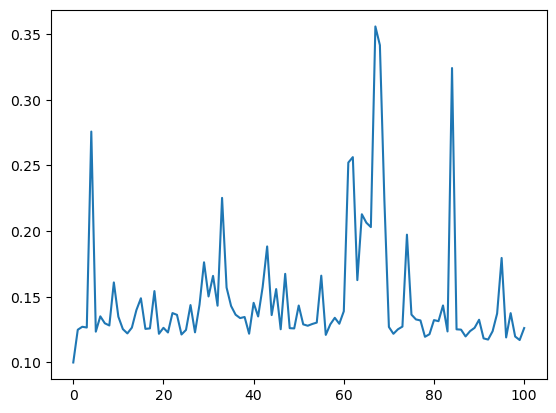

In [25]:
plt.plot(cru_obj.t, cru_obj.cs_result[:,10,10])
plt.show()

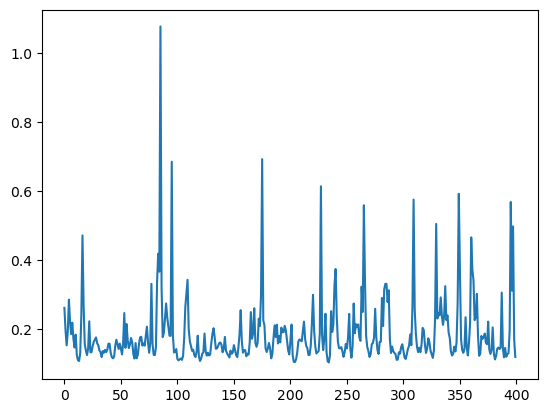

In [12]:
plt.plot(cru_obj.ci_result[-1, -1, :])
plt.show()

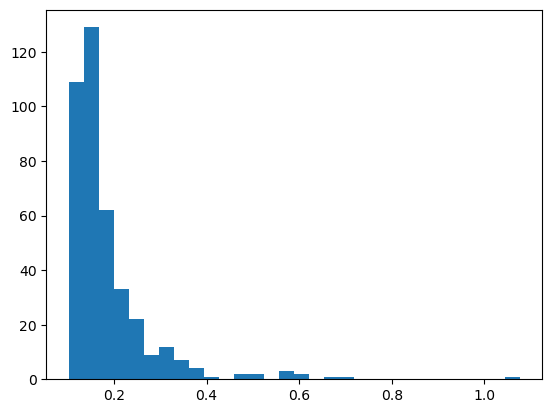

In [13]:
plt.hist(cru_obj.ci_result[-1, -1, :], bins=30)
plt.show()

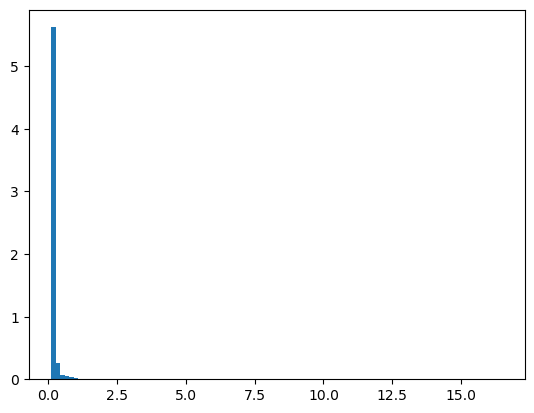

In [14]:
plt.hist(cru_obj.cs.reshape(-1), bins=100, density=True)
plt.show()

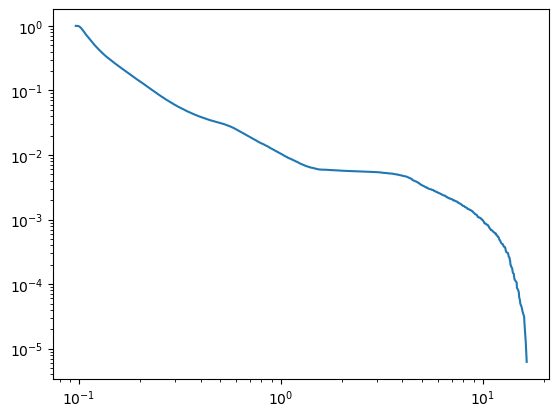

In [15]:
def ccdf(arr):
    ps = np.arange(1, len(arr)+1) / len(arr)
    vals = np.sort(arr)[::-1]
    return ps, vals

ps, bins = ccdf(cru_obj.cs.reshape(-1))
plt.plot(bins, ps)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [16]:
from scipy.fft import fft2, ifft2, fftfreq, fftshift, ifftshift

In [17]:
modes = ifftshift(fft2(fftshift((cru_obj.ci - cru_obj.ci.mean())), norm="ortho"))

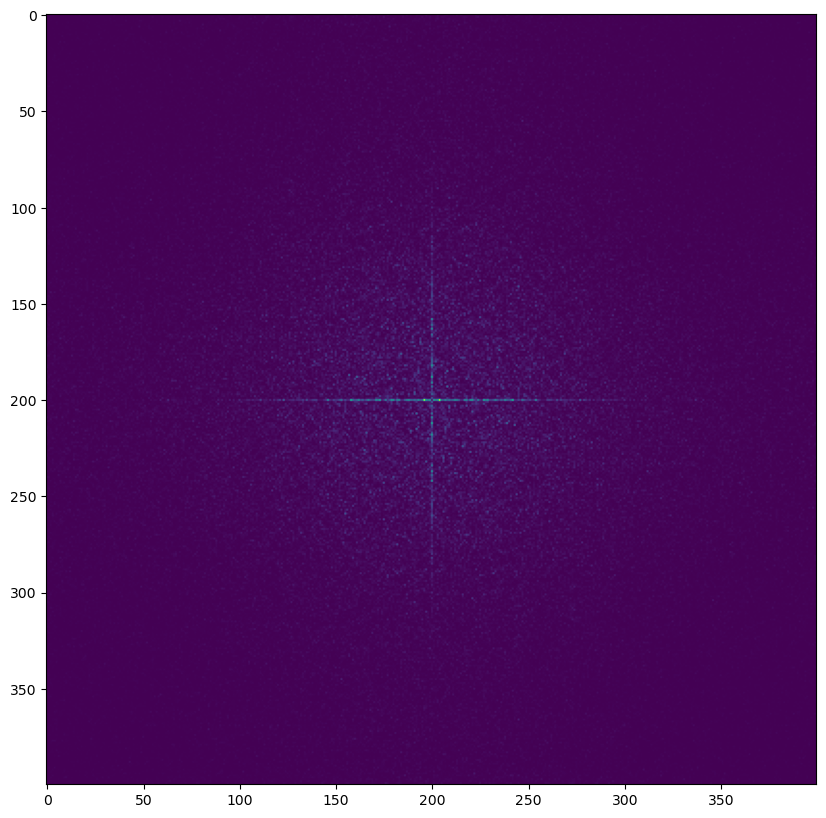

In [18]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(np.abs(modes)**2)
plt.show()

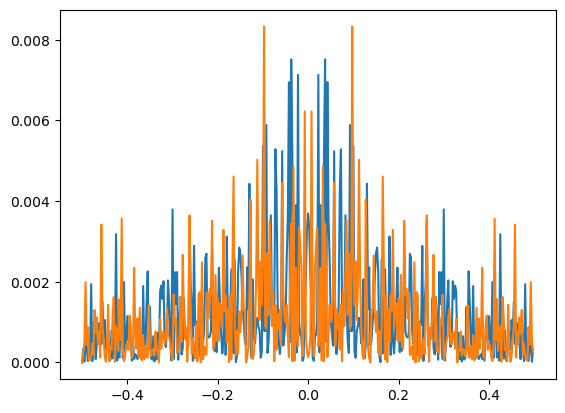

In [19]:
freqs = fftshift(fftfreq(modes[0,:].shape[0]))
plt.plot(freqs, np.abs(modes)[:, 0]**2)
plt.plot(freqs, np.abs(modes)[0, :]**2)
plt.show()

In [20]:
autocor = ifftshift(ifft2(fftshift(np.abs(modes)**2), norm="ortho"))

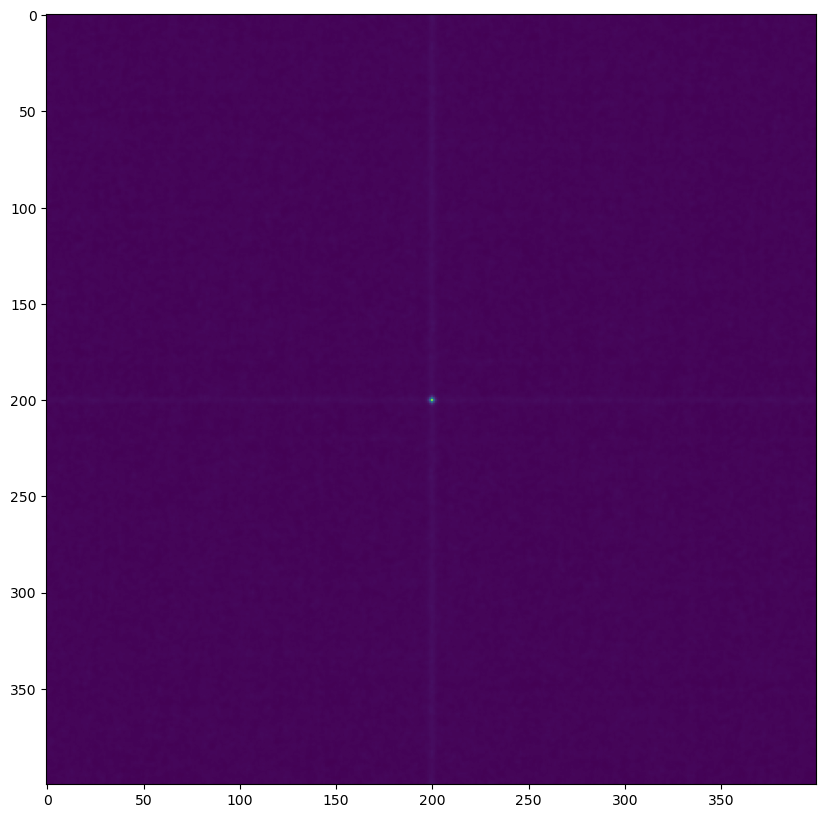

In [21]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(autocor.real)
plt.show()

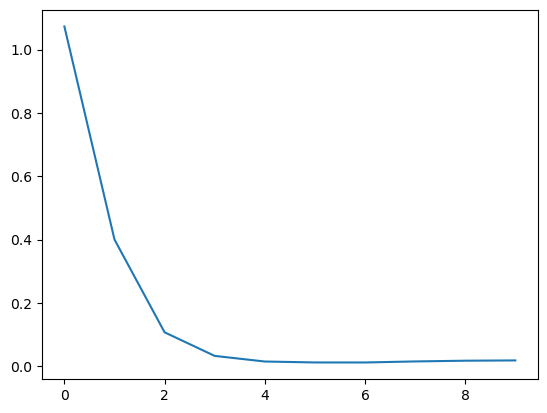

In [22]:
plt.plot(autocor[autocor.shape[0]//2, (autocor.shape[0]//2):(autocor.shape[0]//2+10)].real)
plt.show()